# CPLEX / OR-Tools MCMF：精确 SSG 的规模实验

服务器运行 `benchmark_cplex_mcmf_ssg.py`，本 notebook **只读取本地结果并画图，不运行求解器**。图采用参考图的双面板布局：左侧分组柱状图与误差棒、右侧规模增长折线图；时间轴为对数，右图车辆轴也为对数。

默认服务器命令：
```bash
python -m pip install -r requirements-benchmark.txt
python benchmark_cplex_mcmf_ssg.py --output-dir results/cplex_mcmf_ssg/server_run
```
默认 3 个场景 × 6 个规模 × 10 个种子 × 4 种方法。车辆数为 `100 500 1000 2000 3000 6000`，每档订单数为车辆数的 5 倍。可以用 `--vehicle-counts` 调整规模，或用 `--scenarios reloc_rich aev_joint` 只运行两种有利结构。

将服务器结果目录复制到本地。绘图只需要其中的 `raw_results.csv` 和 `metadata.json`；完整的 `inputs/` NPZ、JSON、逐次事件、汇总表和配对加速表可以另外归档。每个场景都保留全部随机种子，不按运行速度筛选。

- `adp_control`：50% AEV，站点数约为 V/5、地区数约为 V/10。
- `reloc_rich`：50% AEV，站点数约为 V/5、地区数为 2V。
- `aev_joint`：90% AEV，站点数与地区数均为 V。
- 可选 `fixed_candidates`：地区数为 2V，但每辆 AEV 仍只有约 5 个可行 relocation 候选。

这些预设保留原 ADP 合成 Q 分布和精确缩图规则，每站容量统一为 4。实际可行率、种子、后端版本和参数以结果中的 metadata 为准。

In [1]:
from pathlib import Path
import json
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FixedLocator, NullFormatter
from IPython.display import display, Markdown

# 指向从服务器复制到本地的目录；None 自动选择本项目最新完成的新版实验。
RESULT_DIR = None  # 例如 Path("results/cplex_mcmf_ssg/server_run")
SCENARIOS_TO_PLOT = None  # None 表示所有场景；或 ["reloc_rich", "aev_joint"]
METRICS_TO_PLOT = ("end_to_end_seconds", "solve_seconds")
ERROR_BARS = "std"  # "std"：样本标准差；"sem"：均值标准误；"none"：无误差棒
REQUIRE_COMPLETE = True  # 默认拒绝把中断/失败实验当成完整实验作图
SAVE_FIGURES = True
FIGURE_SIZE = (21.2, 7.2)
EXPORT_DPI = 150  # PNG 为 3180 × 1080，与参考图比例相同


## 读取并核查数据

默认要求完整运行、无重复记录、每种方法使用相同种子、同一输入下最优目标一致。总时间包含量化与验证、缩图、建图、求解和解码；`solve_seconds` 包含后端建模与解码，不是优化器内核单独计时。输入生成和文件保存不计入两项时间。

同一完整图或缩图只构建一次供两个后端使用，但每种方法的总时间都计入该图的完整构建耗时。

In [2]:
result_dir = Path(r"results/cplex_mcmf_ssg") 
metadata = json.loads((result_dir / "metadata.json").read_text())
if metadata.get("schema_version") != 2:
    raise ValueError("本 notebook 对应新版场景实验 schema_version=2，请使用更新后的计时脚本。")
if REQUIRE_COMPLETE and metadata["run_status"] != "completed":
    raise ValueError(f"实验尚未完成：{metadata['run_status']}。请先在服务器 --resume。")
raw = pd.read_csv(result_dir / "raw_results.csv")
required = {"case_id", "case_complete", "scenario", "method", "seed", "objective_int", "objective_match",
            "vehicles", "requests", "charging", "relocation", "end_to_end_seconds", "solve_seconds"}
if not required.issubset(raw.columns):
    raise ValueError(f"缺少字段：{sorted(required - set(raw.columns))}")
for column in ("case_complete", "objective_match"):
    raw[column] = raw[column].astype(str).str.lower().isin(["true", "1"])
if raw.duplicated(["case_id", "method"]).any():
    raise ValueError("同一输入/方法有重复行；请勿把不同实验的 CSV 直接拼接。")
if REQUIRE_COMPLETE and (len(raw) != metadata["planned_rows"] or not raw.case_complete.all()):
    raise ValueError("实际记录数量或完整性与计划不符。")
if not REQUIRE_COMPLETE:
    display(Markdown("**当前允许查看未完成实验；不会将缺失种子补成零，也不据此形成正式结论。**"))
    raw = raw.loc[raw.case_complete].copy()
if raw.empty or not raw.objective_match.all():
    raise ValueError("没有完整记录，或存在最优目标不一致的实例。")
if raw.groupby("case_id").objective_int.nunique().max() != 1:
    raise ValueError("同一输入下各算法的最优目标不一致。")
expected_methods = set(metadata["experiment_settings"]["methods"])
expected_seeds = set(metadata["experiment_settings"]["seeds"])
for case_id, group in raw.groupby("case_id"):
    if set(group.method) != expected_methods:
        raise ValueError(f"{case_id} 缺少方法。")
scale_keys = ["scenario", "vehicles", "requests", "charging", "relocation"]
if REQUIRE_COMPLETE:
    for keys, group in raw.groupby(scale_keys + ["method"]):
        if set(group.seed) != expected_seeds:
            raise ValueError(f"{keys} 的种子不完整。")
    expected_scales = {
        (spec["scenario"], *[spec["scale"][k] for k in ["vehicles", "requests", "charging", "relocation"]])
        for spec in metadata["experiment_settings"]["case_specs"]
    }
    actual_scales = set(raw[scale_keys].itertuples(index=False, name=None))
    if actual_scales != expected_scales:
        raise ValueError("场景或规模与计划不符。")
for metric in ("graph_build_seconds", "solve_seconds", "end_to_end_seconds"):
    if not np.isfinite(raw[metric]).all() or (raw[metric] <= 0).any():
        raise ValueError(f"{metric} 含无效或非正耗时，不能画对数图。")
if not np.allclose(raw.end_to_end_seconds, raw.graph_build_seconds + raw.solve_seconds,
                   rtol=1e-10, atol=1e-12):
    raise ValueError("总时间不等于构建时间加求解时间。")
scenario_order = list(dict.fromkeys(spec["scenario"] for spec in metadata["experiment_settings"]["case_specs"]))
scenarios = scenario_order if SCENARIOS_TO_PLOT is None else list(SCENARIOS_TO_PLOT)
if not set(scenarios).issubset(set(raw.scenario)):
    raise ValueError("SCENARIOS_TO_PLOT 含结果中没有的场景。")
figure_dir = result_dir / "figures"
if SAVE_FIGURES:
    figure_dir.mkdir(exist_ok=True)
print(f"读取：{result_dir}")
print(f"{raw.case_id.nunique()} 个输入；{len(raw)} 次求解；每档 {len(expected_seeds)} 个种子；所有目标一致。")
display(raw.groupby(scale_keys, sort=False).agg(
    AEV=("aev_vehicles", "first"), seeds=("seed", "nunique"), methods=("method", "nunique"),
    request_density=("request_density", "first"), charge_density=("charge_density", "first"),
    reloc_density=("reloc_density", "first"), station_capacity=("fixed_charge_capacity", "first")
).reset_index())


读取：results/cplex_mcmf_ssg
180 个输入；720 次求解；每档 10 个种子；所有目标一致。


,scenario,vehicles,requests,charging,relocation,AEV,seeds,methods,request_density,charge_density,reloc_density,station_capacity
0,adp_control,100,500,20,10,50,10,4,0.016,0.20,0.4,4
1,adp_control,500,2500,100,50,250,10,4,0.010,0.05,0.1,4
2,adp_control,1000,5000,200,100,500,10,4,0.010,0.05,0.1,4
3,adp_control,2000,10000,400,200,1000,10,4,0.010,0.05,0.1,4
4,adp_control,3000,15000,600,300,1500,10,4,0.010,0.05,0.1,4
5,adp_control,6000,30000,1200,600,3000,10,4,0.010,0.05,0.1,4
6,reloc_rich,100,500,20,200,50,10,4,0.016,0.20,0.1,4
7,reloc_rich,500,2500,100,1000,250,10,4,0.010,0.05,0.1,4
8,reloc_rich,1000,5000,200,2000,500,10,4,0.010,0.05,0.1,4
9,reloc_rich,2000,10000,400,4000,1000,10,4,0.010,0.05,0.1,4


In [3]:
raw_reloc_rich = raw.loc[raw.scenario == "reloc_rich"].copy()
raw_reloc_rich

,case_id,case_complete,scenario,scenario_title,scale_index,scale_label,repeat,seed,execution_index,graph_group_index,...,status,backend,mcmf_backend,warmed_up,cost_scale,uses_primal_dual,objective_gap_int,objective_match,input_file,input_sha256
240,reloc_rich/v100_r500_c20_z200/seed2101,True,reloc_rich,Relocation-rich,0,100V/500R,0,2101,1,0,...,OPTIMAL,docplex_network_cplex,ortools,True,10000,False,0,True,inputs/reloc_rich/v100_r500_c20_z200/seed2101.npz,dd22370364111c42fac2e63382bbfe84d664ef0e860641...
241,reloc_rich/v100_r500_c20_z200/seed2101,True,reloc_rich,Relocation-rich,0,100V/500R,0,2101,0,0,...,OPTIMAL,ortools_cost_scaling,ortools,True,10000,False,0,True,inputs/reloc_rich/v100_r500_c20_z200/seed2101.npz,dd22370364111c42fac2e63382bbfe84d664ef0e860641...
242,reloc_rich/v100_r500_c20_z200/seed2101,True,reloc_rich,Relocation-rich,0,100V/500R,0,2101,3,1,...,OPTIMAL,docplex_network_cplex,ortools,True,10000,False,0,True,inputs/reloc_rich/v100_r500_c20_z200/seed2101.npz,dd22370364111c42fac2e63382bbfe84d664ef0e860641...
243,reloc_rich/v100_r500_c20_z200/seed2101,True,reloc_rich,Relocation-rich,0,100V/500R,0,2101,2,1,...,OPTIMAL,ortools_cost_scaling,ortools,True,10000,False,0,True,inputs/reloc_rich/v100_r500_c20_z200/seed2101.npz,dd22370364111c42fac2e63382bbfe84d664ef0e860641...
244,reloc_rich/v100_r500_c20_z200/seed2102,True,reloc_rich,Relocation-rich,0,100V/500R,1,2102,3,1,...,OPTIMAL,docplex_network_cplex,ortools,True,10000,False,0,True,inputs/reloc_rich/v100_r500_c20_z200/seed2102.npz,e9274a0d565b605ef2dec30aa67242848ae5b2376d726c...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
475,reloc_rich/v6000_r30000_c1200_z12000/seed2109,True,reloc_rich,Relocation-rich,5,6000V/30000R,8,2109,0,0,...,OPTIMAL,ortools_cost_scaling,ortools,True,10000,False,0,True,inputs/reloc_rich/v6000_r30000_c1200_z12000/se...,744f556039b8fef8aab9ca3591483c7af3b0441ac5908e...
476,reloc_rich/v6000_r30000_c1200_z12000/seed2110,True,reloc_rich,Relocation-rich,5,6000V/30000R,9,2110,0,0,...,OPTIMAL,docplex_network_cplex,ortools,True,10000,False,0,True,inputs/reloc_rich/v6000_r30000_c1200_z12000/se...,eb9c0a1d9957d6ab26587bebe923584728e78b63fb4f13...
477,reloc_rich/v6000_r30000_c1200_z12000/seed2110,True,reloc_rich,Relocation-rich,5,6000V/30000R,9,2110,1,0,...,OPTIMAL,ortools_cost_scaling,ortools,True,10000,False,0,True,inputs/reloc_rich/v6000_r30000_c1200_z12000/se...,eb9c0a1d9957d6ab26587bebe923584728e78b63fb4f13...
478,reloc_rich/v6000_r30000_c1200_z12000/seed2110,True,reloc_rich,Relocation-rich,5,6000V/30000R,9,2110,2,1,...,OPTIMAL,docplex_network_cplex,ortools,True,10000,False,0,True,inputs/reloc_rich/v6000_r30000_c1200_z12000/se...,eb9c0a1d9957d6ab26587bebe923584728e78b63fb4f13...


In [10]:
raw_reloc_rich.columns

Index(['case_id', 'case_complete', 'scenario', 'scenario_title', 'scale_index',
       'scale_label', 'repeat', 'seed', 'execution_index', 'graph_group_index',
       'case_distribution', 'method', 'method_label', 'vehicles', 'requests',
       'charging', 'relocation', 'aev_vehicles', 'aev_ratio',
       'request_density', 'charge_density', 'reloc_density',
       'fixed_charge_capacity', 'feasible_edges', 'request_edges',
       'charge_edges', 'relocation_edges', 'retained_request_edges',
       'retained_charge_edges', 'retained_relocation_edges', 'graph_nodes',
       'graph_edges', 'original_graph_edges', 'edge_reduction_ratio',
       'reduction_rounds', 'generation_seconds', 'graph_build_seconds',
       'solve_seconds', 'end_to_end_seconds', 'time_ms', 'reward',
       'objective_int', 'objective_q', 'flow', 'status', 'backend',
       'mcmf_backend', 'warmed_up', 'cost_scale', 'uses_primal_dual',
       'objective_gap_int', 'objective_match', 'input_file', 'input_sha256'],
  

In [ ]:
# 按规模和方法，对全部种子取均值；Time = solve_seconds × 1000，不含缩图。
reloc_rich_dimensions = ["vehicles", "requests", "charging", "relocation"]
reloc_rich_method_order = ["cplex", "mcmf", "ssg_cplex", "ssg_mcmf"]
reloc_rich_method_names = {
    "cplex": "CPLEX",
    "mcmf": "MCMF (OR-Tools)",
    "ssg_cplex": "CPLEX + SSG",
    "ssg_mcmf": "MCMF (OR-Tools) + SSG",
}
reloc_rich_mean = (
    raw_reloc_rich.groupby(reloc_rich_dimensions + ["method"], as_index=False)
    .agg(reward=("reward", "mean"), time_ms=("solve_seconds", "mean"))
)

In [11]:
# 按规模和方法，对全部种子取均值；Time = solve_seconds × 1000，不含缩图。
reloc_rich_dimensions = ["vehicles", "requests", "charging", "relocation"]
reloc_rich_method_order = ["cplex", "mcmf", "ssg_cplex", "ssg_mcmf"]
reloc_rich_method_names = {
    "cplex": "CPLEX",
    "mcmf": "MCMF (OR-Tools)",
    "ssg_cplex": "CPLEX + SSG",
    "ssg_mcmf": "MCMF (OR-Tools) + SSG",
}
reloc_rich_mean = (
    raw_reloc_rich.groupby(reloc_rich_dimensions + ["method"], as_index=False)
    .agg(reward=("reward", "mean"), time_ms=('end_to_end_seconds', "mean"))
)
reloc_rich_mean["method_order"] = reloc_rich_mean["method"].map(
    {method: index for index, method in enumerate(reloc_rich_method_order)}
)
reloc_rich_mean = (
    reloc_rich_mean.sort_values(reloc_rich_dimensions + ["method_order"])
    .drop(columns="method_order")
    .reset_index(drop=True)
)
reloc_rich_mean["time_ms"] = reloc_rich_mean["time_ms"] * 1000

def reloc_rich_latex_number(value):
    # 只格式化展示值，原始均值不变；恰好 1000 仍显示 1000.00。
    if abs(value) > 1000:
        mantissa, exponent = f"{value:.2e}".split("e")
        return rf"${mantissa}\times 10^{{{int(exponent)}}}$"
    return f"{value:.2f}"

# AAAI 双栏正文中使用跨栏浮动表格，避免八列内容覆盖右栏。
reloc_rich_latex_lines = [
    r"\begin{table*}[t]",
    r"\centering",
    r"\small",
    r"\begin{tabular}{@{}llrrrrrr@{}}",
    r"\toprule",
    r"ID & Method & NV & NA & NC & NR & R (\$) & Time (ms) \\",
    r"\midrule",
]
for num, row in enumerate(reloc_rich_mean.itertuples(index=False), start=1):
    result = f"{num} & {reloc_rich_method_names[row.method]} & "
    result += f"{int(row.vehicles)} & {int(row.requests)} & "
    result += f"{int(row.charging)} & {int(row.relocation)} & "
    result += f"{reloc_rich_latex_number(row.reward)} & {reloc_rich_latex_number(row.time_ms)}" + r" \\"
    reloc_rich_latex_lines.append(result)
    if num < len(reloc_rich_mean):
        next_row = reloc_rich_mean.iloc[num]
        if any(getattr(row, key) != next_row[key] for key in reloc_rich_dimensions):
            reloc_rich_latex_lines.append(r"\midrule")
reloc_rich_latex_lines.extend([
    r"\bottomrule",
    r"\end{tabular}",
    r"\caption{Scalability on relocation-rich instances. Means over 10 random seeds. "
    r"NV, NA, NC, and NR denote numbers of vehicles, requests, battery-swapping stations, "
    r"and relocation zones, respectively. $R$ is the assignment reward. MCMF uses OR-Tools. "
    r"Time is the backend solve-call time in milliseconds, excluding graph construction "
    r"and SSG preprocessing.}",
    r"\label{tab:reloc_rich_scalability}",
    r"\end{table*}",
])
reloc_rich_latex = "\n".join(reloc_rich_latex_lines)
print(reloc_rich_latex)

# 导言区需要 \usepackage{booktabs}。
reloc_rich_latex_path = result_dir / "tables" / "reloc_rich_solve_time.tex"
reloc_rich_latex_path.parent.mkdir(parents=True, exist_ok=True)
_ = reloc_rich_latex_path.write_text(reloc_rich_latex + "\n", encoding="utf-8")


\begin{table*}[t]
\centering
\small
\begin{tabular}{@{}llrrrrrr@{}}
\toprule
ID & Method & NV & NA & NC & NR & R (\$) & Time (ms) \\
\midrule
1 & CPLEX & 100 & 500 & 20 & 200 & $3.19\times 10^{3}$ & 73.87 \\
2 & MCMF (OR-Tools) & 100 & 500 & 20 & 200 & $3.19\times 10^{3}$ & 2.76 \\
3 & CPLEX + SSG & 100 & 500 & 20 & 200 & $3.19\times 10^{3}$ & 17.96 \\
4 & MCMF (OR-Tools) + SSG & 100 & 500 & 20 & 200 & $3.19\times 10^{3}$ & 5.49 \\
\midrule
5 & CPLEX & 500 & 2500 & 100 & 1000 & $1.69\times 10^{4}$ & 900.74 \\
6 & MCMF (OR-Tools) & 500 & 2500 & 100 & 1000 & $1.69\times 10^{4}$ & 39.22 \\
7 & CPLEX + SSG & 500 & 2500 & 100 & 1000 & $1.69\times 10^{4}$ & 297.24 \\
8 & MCMF (OR-Tools) + SSG & 500 & 2500 & 100 & 1000 & $1.69\times 10^{4}$ & 70.23 \\
\midrule
9 & CPLEX & 1000 & 5000 & 200 & 2000 & $3.44\times 10^{4}$ & $3.07\times 10^{3}$ \\
10 & MCMF (OR-Tools) & 1000 & 5000 & 200 & 2000 & $3.44\times 10^{4}$ & 151.22 \\
11 & CPLEX + SSG & 1000 & 5000 & 200 & 2000 & $3.44\times 10^{4}$ & $1

plot_reloc_rich

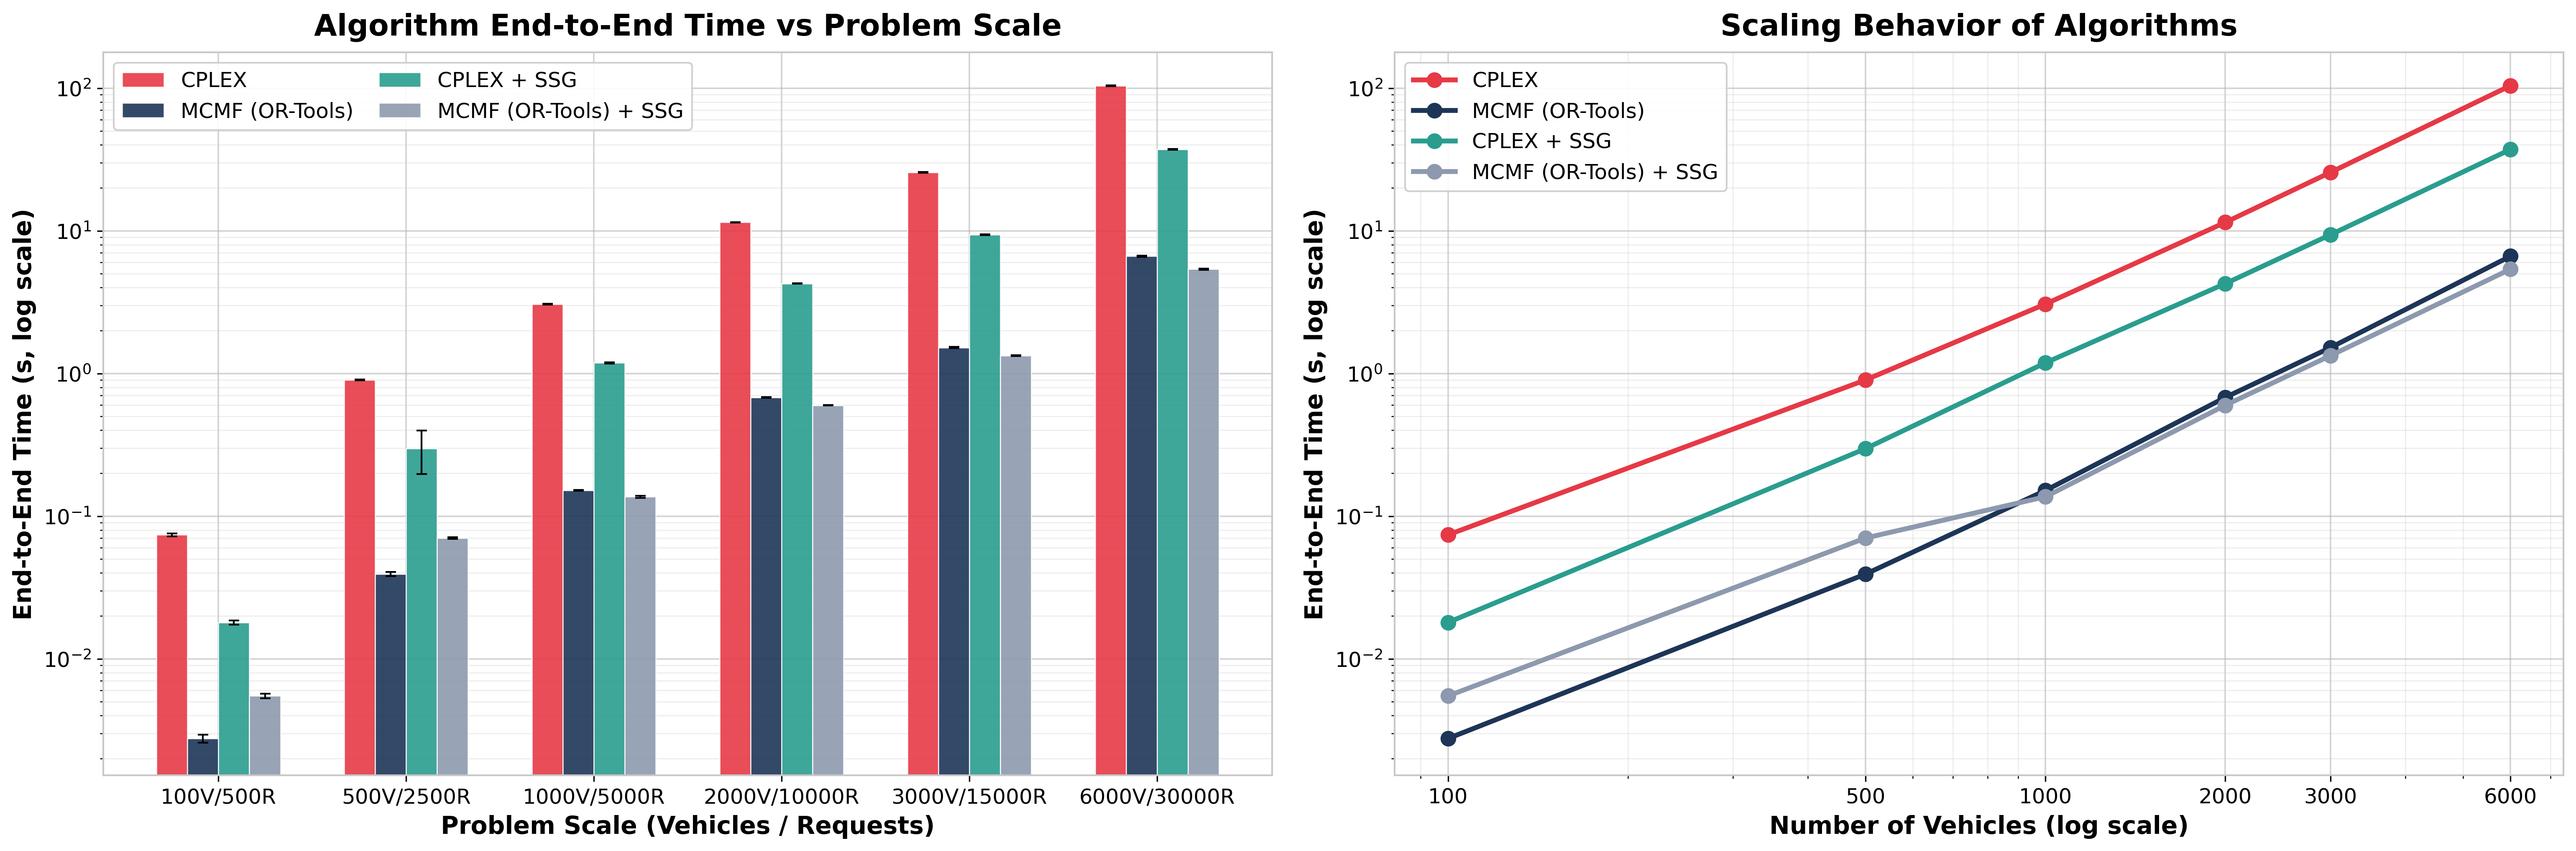

In [12]:
METHOD_ORDER = ("cplex", "mcmf", "ssg_cplex", "ssg_mcmf")
COLORS = {"cplex": "#E63946", "mcmf": "#1D3557", "ssg_cplex": "#2A9D8F", "ssg_mcmf": "#8D99AE"}
METHOD_NAMES = metadata["methods"]
METRIC_LABELS = {
    "end_to_end_seconds": ("Algorithm End-to-End Time vs Problem Scale", "End-to-End Time (s, log scale)"),
    "solve_seconds": ("Algorithm Solve Time vs Problem Scale", "Solve Time (s, log scale)"),
}

metric = "end_to_end_seconds"
frame = raw.copy()
scenario = "reloc_rich"
if metric not in METRIC_LABELS or ERROR_BARS not in {"std", "sem", "none"}:
    raise ValueError("未知计时口径或误差棒类型")
selected = frame.loc[frame.scenario.eq(scenario)].copy()
dimensions = selected[["vehicles", "requests", "charging", "relocation"]].drop_duplicates().sort_values("vehicles")
if dimensions.vehicles.duplicated().any():
    raise ValueError("一个场景中同一车辆数存在多个 R/C/Z 配置，请分开绘图。")
counts = dimensions.vehicles.to_numpy()
labels = [f"{int(row.vehicles)}V/{int(row.requests)}R" for row in dimensions.itertuples()]
methods = [method for method in METHOD_ORDER if method in set(selected.method)]
stats = selected.groupby(["vehicles", "method"])[metric].agg(["mean", "std", "count"])
stats["std"] = stats["std"].fillna(0.0)
if stats["mean"].isna().any():
    raise ValueError("某个规模缺少算法结果")
display_floor = float(stats["mean"].min()) * 0.1
exported = stats.reset_index().assign(scenario=scenario, metric=metric, error_bars=ERROR_BARS)
style = {
    "font.family": "DejaVu Sans", "font.size": 12,
    "axes.titlesize": 17, "axes.titleweight": "bold",
    "axes.labelsize": 14, "axes.labelweight": "bold",
    "xtick.labelsize": 12, "ytick.labelsize": 12,
    "legend.fontsize": 12, "axes.edgecolor": "#C8C8C8", "axes.linewidth": 1,
}
with plt.rc_context(style):
    fig, axes = plt.subplots(1, 2, figsize=FIGURE_SIZE, dpi=300)
    fig.subplots_adjust(left=0.065, right=0.99, bottom=0.13, top=0.93, wspace=0.105)
    x = np.arange(len(counts))
    width = 0.66 / len(methods)
    clipped = False
    for index, method in enumerate(methods):
        group = stats.xs(method, level="method").reindex(counts)
        if group["mean"].isna().any():
            raise ValueError(f"{method} 缺少某个规模，不能补零作图")
        means = group["mean"].to_numpy()
        spread = group["std"].to_numpy()
        if ERROR_BARS == "sem":
            spread = spread / np.sqrt(group["count"].to_numpy())
        elif ERROR_BARS == "none":
            spread = np.zeros_like(spread)
        lower = np.minimum(spread, means - display_floor)
        clipped |= bool(np.any(lower < spread))
        yerr = np.vstack([lower, spread]) if ERROR_BARS != "none" else None
        axes[0].bar(x + (index - (len(methods)-1)/2)*width, means, width,
                    yerr=yerr, color=COLORS[method], alpha=0.9, label=METHOD_NAMES[method],
                    edgecolor="white", linewidth=0.6,
                    error_kw={"ecolor": "black", "elinewidth": 1.0, "capsize": 3, "capthick": 1.0})
        axes[1].plot(counts, means, color=COLORS[method], label=METHOD_NAMES[method],
                        marker="o", markersize=8, linewidth=2.8)
    for axis in axes:
        axis.set_yscale("log")
        axis.set_axisbelow(True)
        axis.grid(which="major", color="#B8B8B8", alpha=0.6, linewidth=0.9)
        axis.grid(which="minor", color="#D0D0D0", alpha=0.35, linewidth=0.7)
        axis.set_ylabel(METRIC_LABELS[metric][1])
    axes[0].set_xticks(x, labels)
    axes[0].set_xlabel("Problem Scale (Vehicles / Requests)")
    axes[0].set_title(METRIC_LABELS[metric][0], pad=10)
    axes[0].legend(loc="upper left", ncol=2, framealpha=0.9, columnspacing=1.2, handlelength=2)
    axes[1].set_xscale("log")
    axes[1].xaxis.set_major_locator(FixedLocator(counts))
    axes[1].set_xticklabels([str(int(n)) for n in counts])
    axes[1].xaxis.set_minor_formatter(NullFormatter())
    axes[1].set_xlabel("Number of Vehicles (log scale)")
    axes[1].set_title("Scaling Behavior of Algorithms", pad=10)
    axes[1].legend(loc="upper left", framealpha=0.9)
    limits = [axis.get_ylim() for axis in axes]
    common_limits = (min(pair[0] for pair in limits), max(pair[1] for pair in limits))
    for axis in axes:
        axis.set_ylim(common_limits)
    if clipped:
        print(f"{scenario}/{metric}：部分误差棒下端超过零，在对数显示下界截断；原始标准差完整保存。")
    if SAVE_FIGURES:
        stem = figure_dir / f"{scenario}_{metric}"
        fig.savefig(stem.with_suffix(".png"), dpi=EXPORT_DPI)
        fig.savefig(stem.with_suffix(".pdf"))
        fig.savefig(stem.with_suffix(".svg"))
        exported.to_csv(figure_dir / f"{scenario}_{metric}_plotted_statistics.csv", index=False)
    plt.show()
    plt.close(fig)



## 双面板作图

各场景独立绘图，绝不把同样车辆数但不同站点/地区数的结果混合。柱高和折线为所有种子的算术平均值；默认误差棒为样本标准差。若标准差下端跨过零，对数图会将其截在正数显示下界并明确提示，原始统计不变。

默认分别导出端到端时间和后端调用时间两张图。标题和纵轴会随计时口径变化，避免把纯求解优势表述为总时间优势。

In [5]:
METHOD_ORDER = ("cplex", "mcmf", "ssg_cplex", "ssg_mcmf")
COLORS = {"cplex": "#E63946", "mcmf": "#1D3557", "ssg_cplex": "#2A9D8F", "ssg_mcmf": "#8D99AE"}
METHOD_NAMES = metadata["methods"]
METRIC_LABELS = {
    "end_to_end_seconds": ("Algorithm End-to-End Time vs Problem Scale", "End-to-End Time (s, log scale)"),
    "solve_seconds": ("Algorithm Solve Time vs Problem Scale", "Solve Time (s, log scale)"),
}

def plot_scenario(frame, scenario, metric="end_to_end_seconds"):
    if metric not in METRIC_LABELS or ERROR_BARS not in {"std", "sem", "none"}:
        raise ValueError("未知计时口径或误差棒类型")
    selected = frame.loc[frame.scenario.eq(scenario)].copy()
    dimensions = selected[["vehicles", "requests", "charging", "relocation"]].drop_duplicates().sort_values("vehicles")
    if dimensions.vehicles.duplicated().any():
        raise ValueError("一个场景中同一车辆数存在多个 R/C/Z 配置，请分开绘图。")
    counts = dimensions.vehicles.to_numpy()
    labels = [f"{int(row.vehicles)}V/{int(row.requests)}R" for row in dimensions.itertuples()]
    methods = [method for method in METHOD_ORDER if method in set(selected.method)]
    stats = selected.groupby(["vehicles", "method"])[metric].agg(["mean", "std", "count"])
    stats["std"] = stats["std"].fillna(0.0)
    if stats["mean"].isna().any():
        raise ValueError("某个规模缺少算法结果")
    display_floor = float(stats["mean"].min()) * 0.1
    exported = stats.reset_index().assign(scenario=scenario, metric=metric, error_bars=ERROR_BARS)
    style = {
        "font.family": "DejaVu Sans", "font.size": 12,
        "axes.titlesize": 17, "axes.titleweight": "bold",
        "axes.labelsize": 14, "axes.labelweight": "bold",
        "xtick.labelsize": 12, "ytick.labelsize": 12,
        "legend.fontsize": 12, "axes.edgecolor": "#C8C8C8", "axes.linewidth": 1,
    }
    with plt.rc_context(style):
        fig, axes = plt.subplots(1, 2, figsize=FIGURE_SIZE, dpi=300)
        fig.subplots_adjust(left=0.065, right=0.99, bottom=0.13, top=0.93, wspace=0.105)
        x = np.arange(len(counts))
        width = 0.66 / len(methods)
        clipped = False
        for index, method in enumerate(methods):
            group = stats.xs(method, level="method").reindex(counts)
            if group["mean"].isna().any():
                raise ValueError(f"{method} 缺少某个规模，不能补零作图")
            means = group["mean"].to_numpy()
            spread = group["std"].to_numpy()
            if ERROR_BARS == "sem":
                spread = spread / np.sqrt(group["count"].to_numpy())
            elif ERROR_BARS == "none":
                spread = np.zeros_like(spread)
            lower = np.minimum(spread, means - display_floor)
            clipped |= bool(np.any(lower < spread))
            yerr = np.vstack([lower, spread]) if ERROR_BARS != "none" else None
            axes[0].bar(x + (index - (len(methods)-1)/2)*width, means, width,
                        yerr=yerr, color=COLORS[method], alpha=0.9, label=METHOD_NAMES[method],
                        edgecolor="white", linewidth=0.6,
                        error_kw={"ecolor": "black", "elinewidth": 1.0, "capsize": 3, "capthick": 1.0})
            axes[1].plot(counts, means, color=COLORS[method], label=METHOD_NAMES[method],
                         marker="o", markersize=8, linewidth=2.8)
        for axis in axes:
            axis.set_yscale("log")
            axis.set_axisbelow(True)
            axis.grid(which="major", color="#B8B8B8", alpha=0.6, linewidth=0.9)
            axis.grid(which="minor", color="#D0D0D0", alpha=0.35, linewidth=0.7)
            axis.set_ylabel(METRIC_LABELS[metric][1])
        axes[0].set_xticks(x, labels)
        axes[0].set_xlabel("Problem Scale (Vehicles / Requests)")
        axes[0].set_title(METRIC_LABELS[metric][0], pad=10)
        axes[0].legend(loc="upper left", ncol=2, framealpha=0.9, columnspacing=1.2, handlelength=2)
        axes[1].set_xscale("log")
        axes[1].xaxis.set_major_locator(FixedLocator(counts))
        axes[1].set_xticklabels([str(int(n)) for n in counts])
        axes[1].xaxis.set_minor_formatter(NullFormatter())
        axes[1].set_xlabel("Number of Vehicles (log scale)")
        axes[1].set_title("Scaling Behavior of Algorithms", pad=10)
        axes[1].legend(loc="upper left", framealpha=0.9)
        limits = [axis.get_ylim() for axis in axes]
        common_limits = (min(pair[0] for pair in limits), max(pair[1] for pair in limits))
        for axis in axes:
            axis.set_ylim(common_limits)
        if clipped:
            print(f"{scenario}/{metric}：部分误差棒下端超过零，在对数显示下界截断；原始标准差完整保存。")
        if SAVE_FIGURES:
            stem = figure_dir / f"{scenario}_{metric}"
            fig.savefig(stem.with_suffix(".png"), dpi=EXPORT_DPI)
            fig.savefig(stem.with_suffix(".pdf"))
            fig.savefig(stem.with_suffix(".svg"))
            exported.to_csv(figure_dir / f"{scenario}_{metric}_plotted_statistics.csv", index=False)
        plt.show()
        plt.close(fig)
    return exported


### ADP control (`adp_control`)

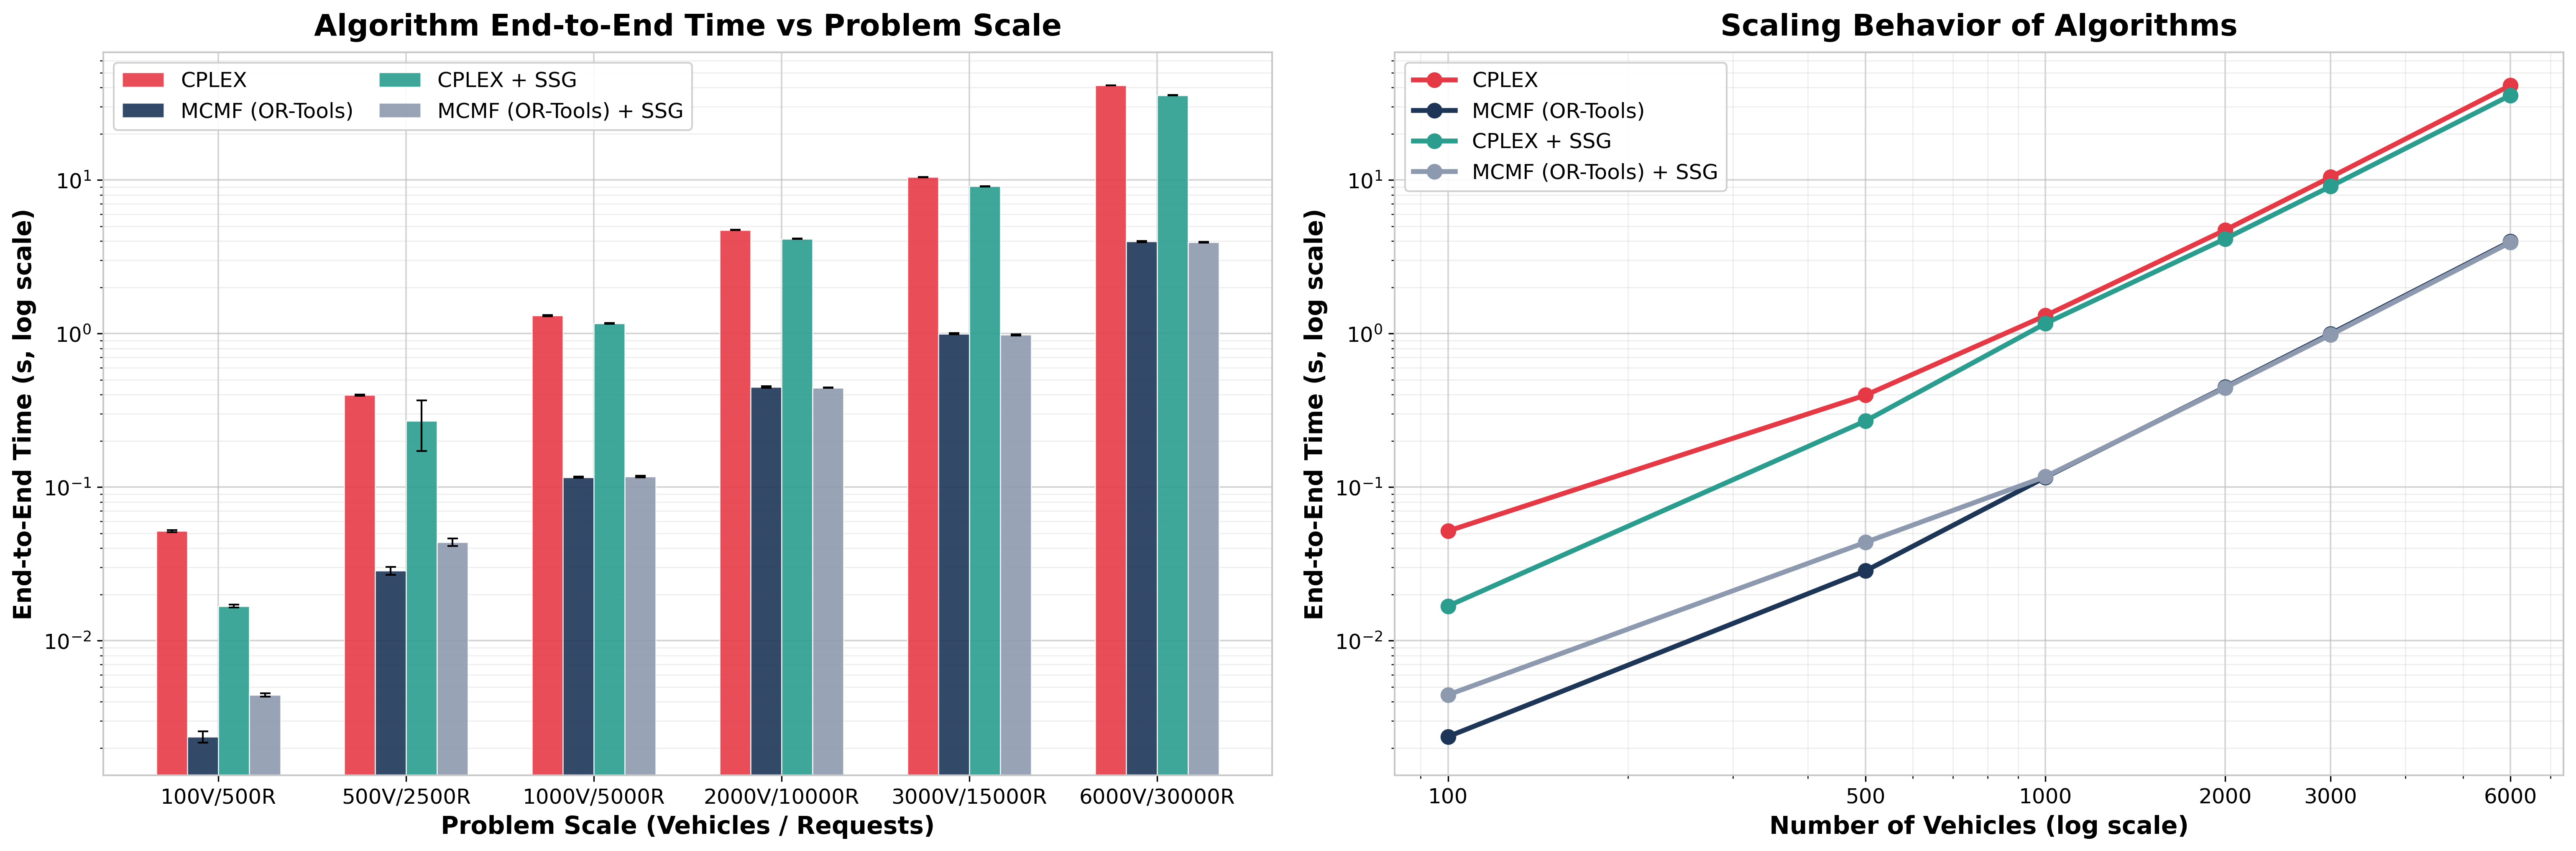

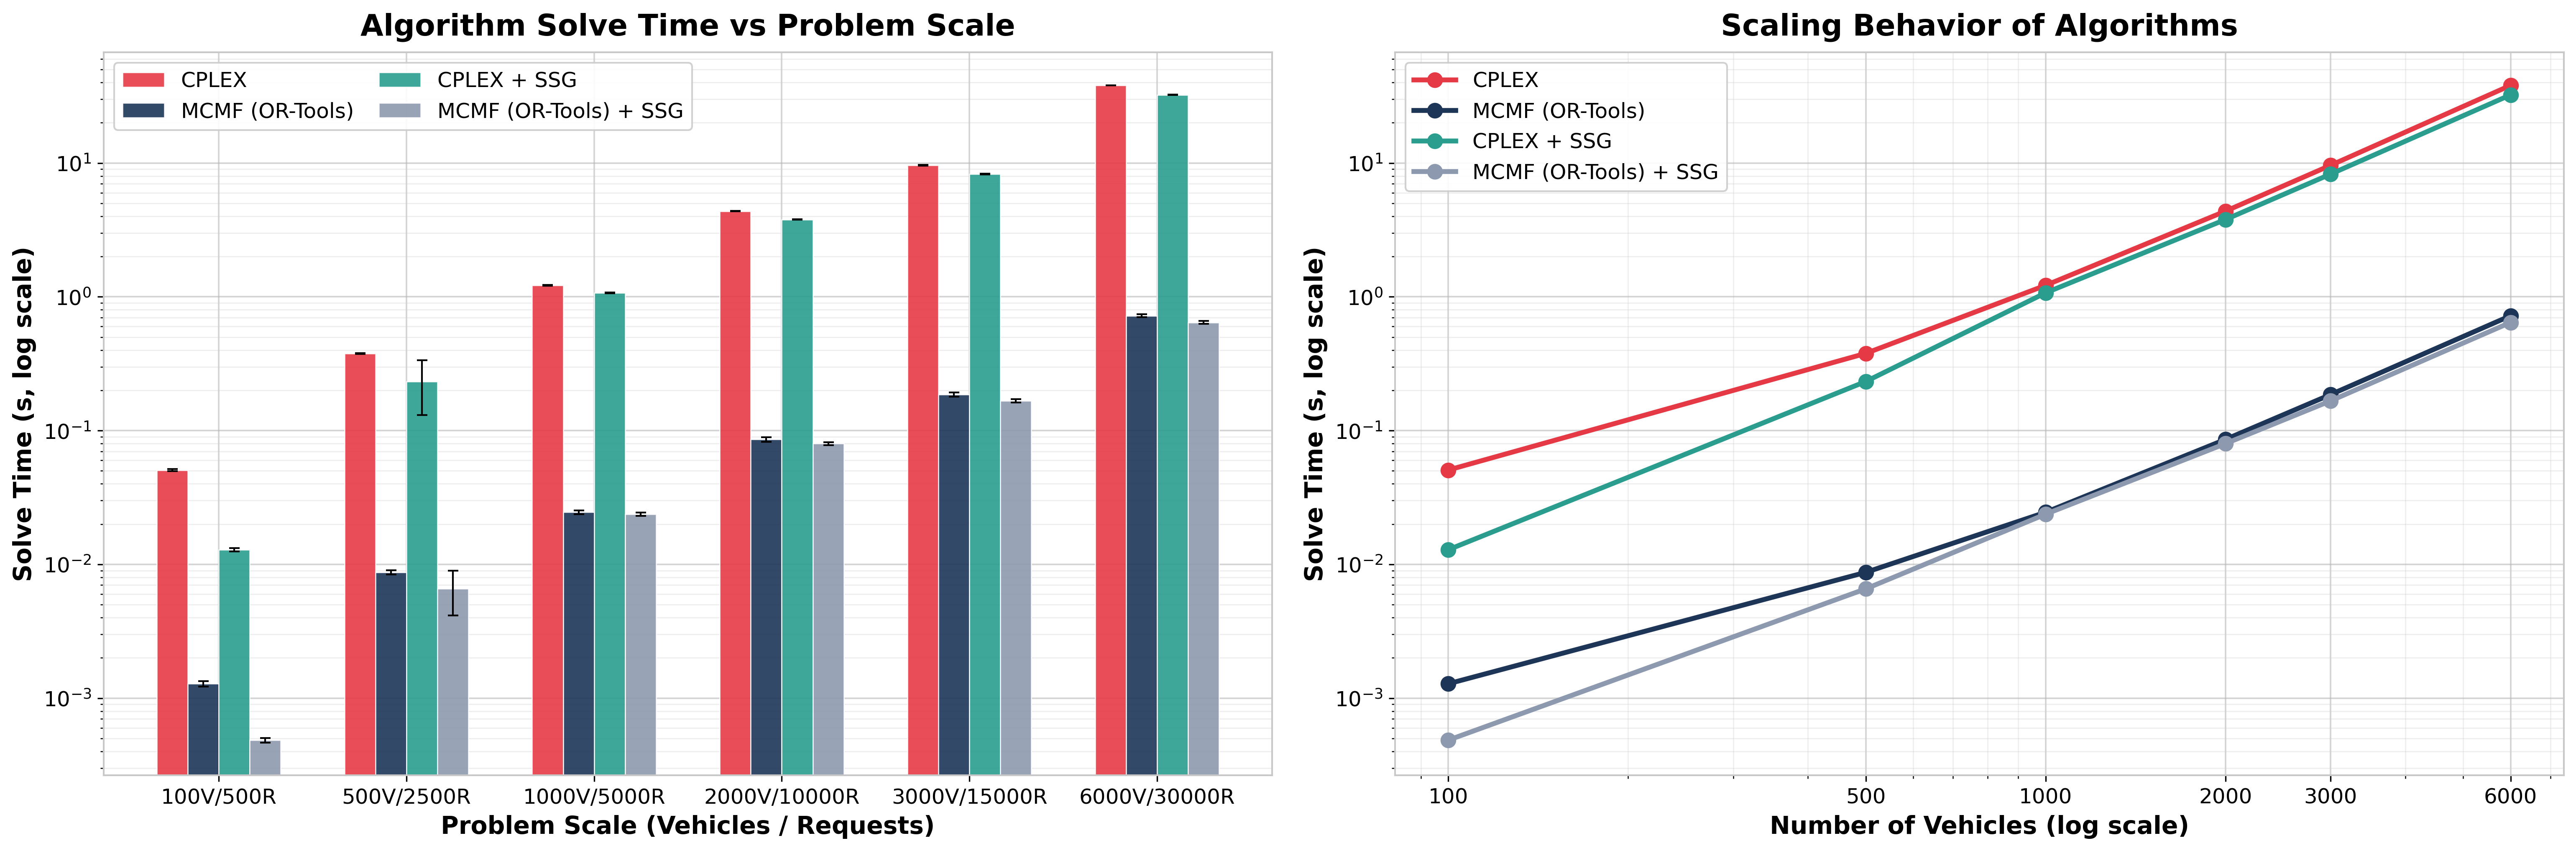

### Relocation-rich (`reloc_rich`)

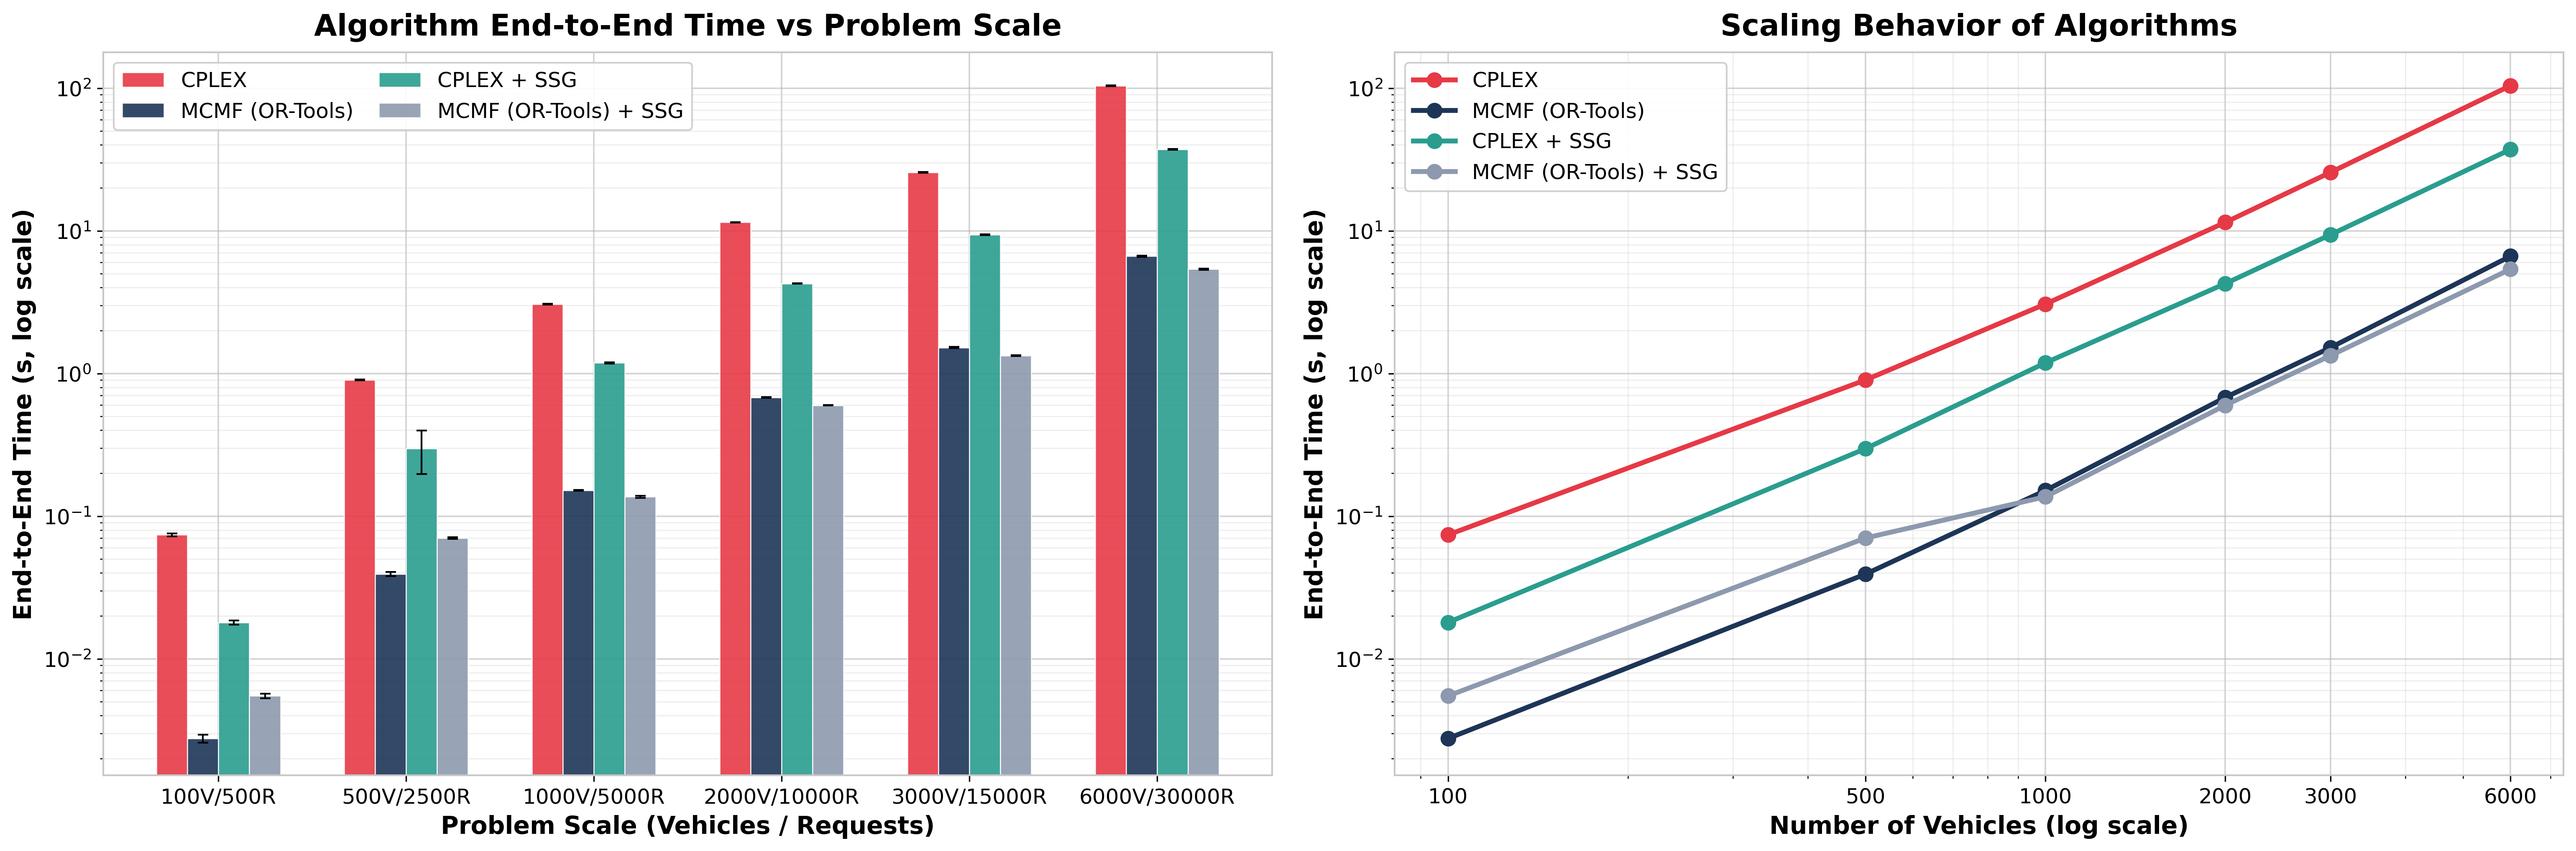

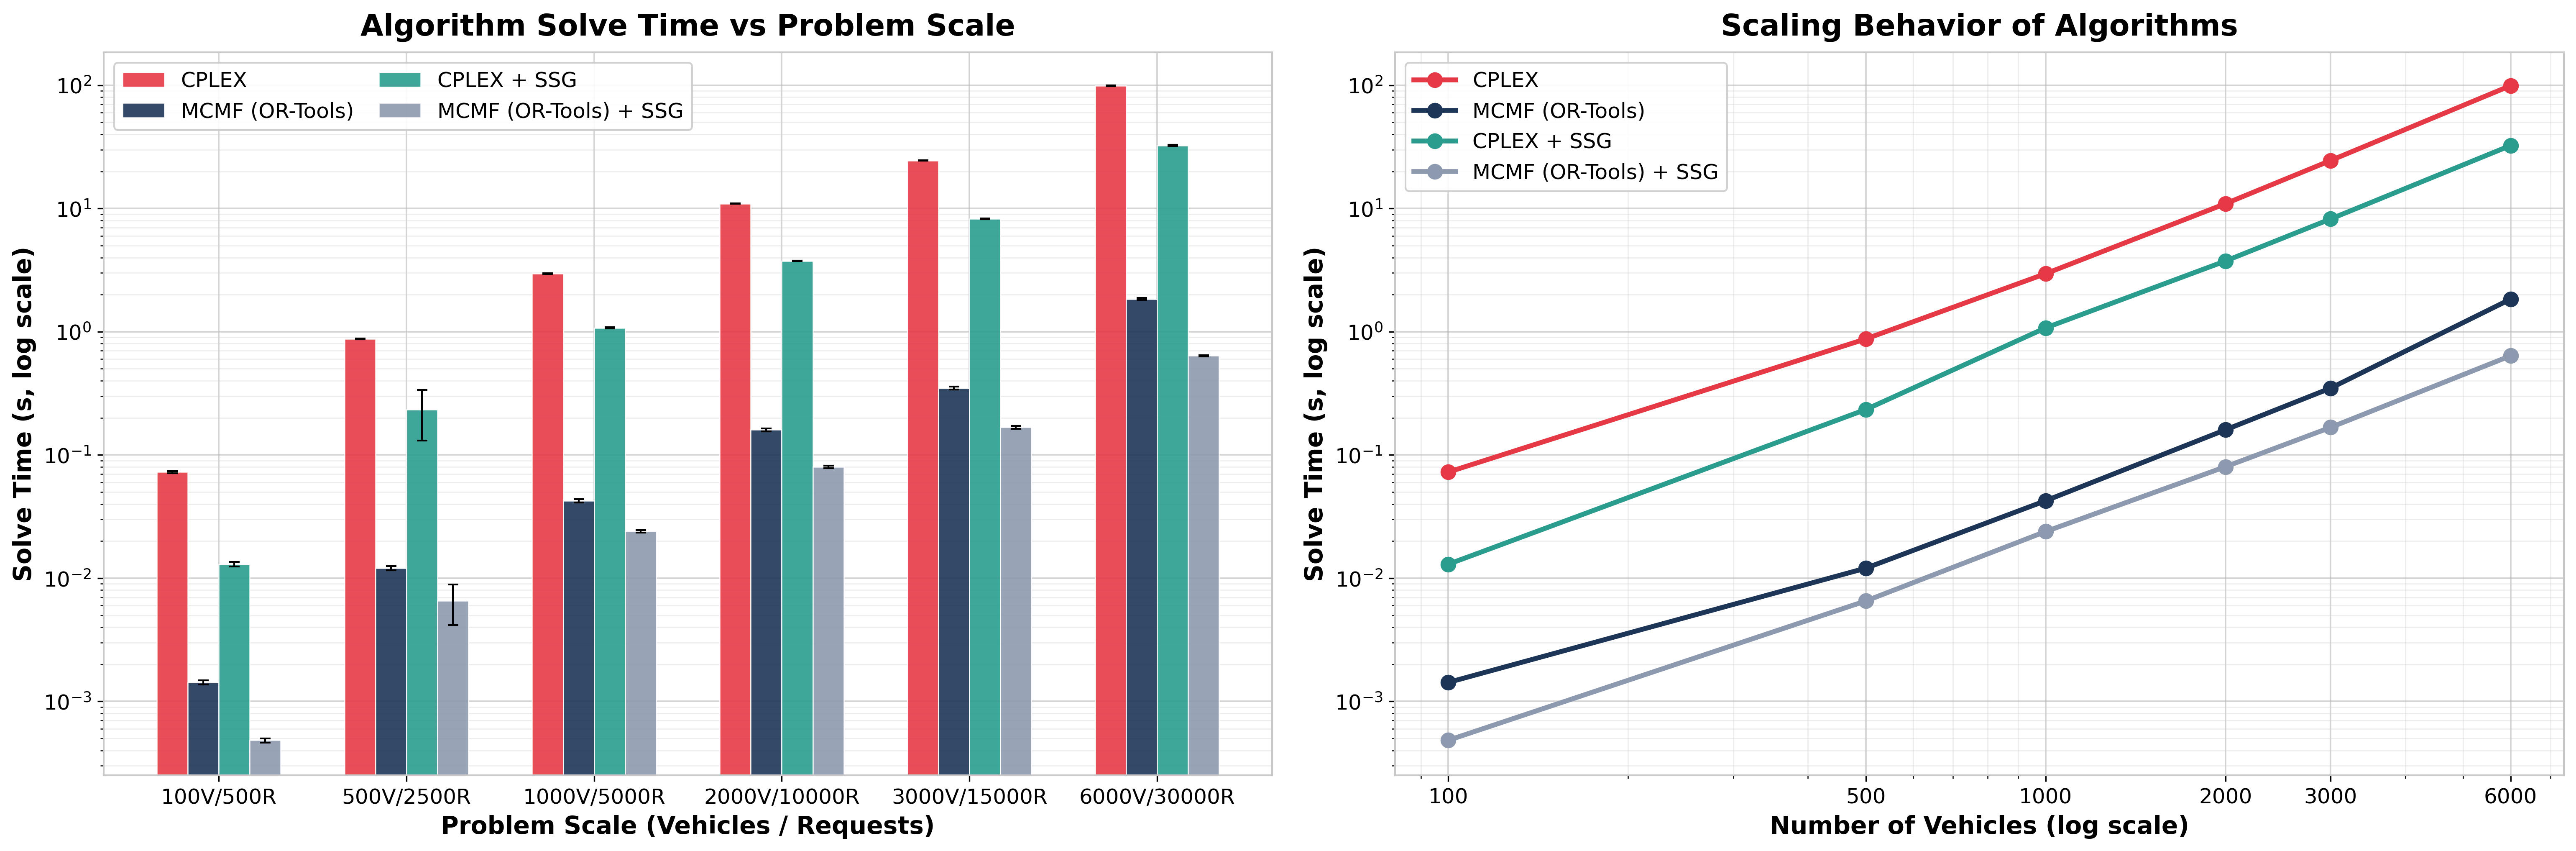

### High AEV, stations and relocation (`aev_joint`)

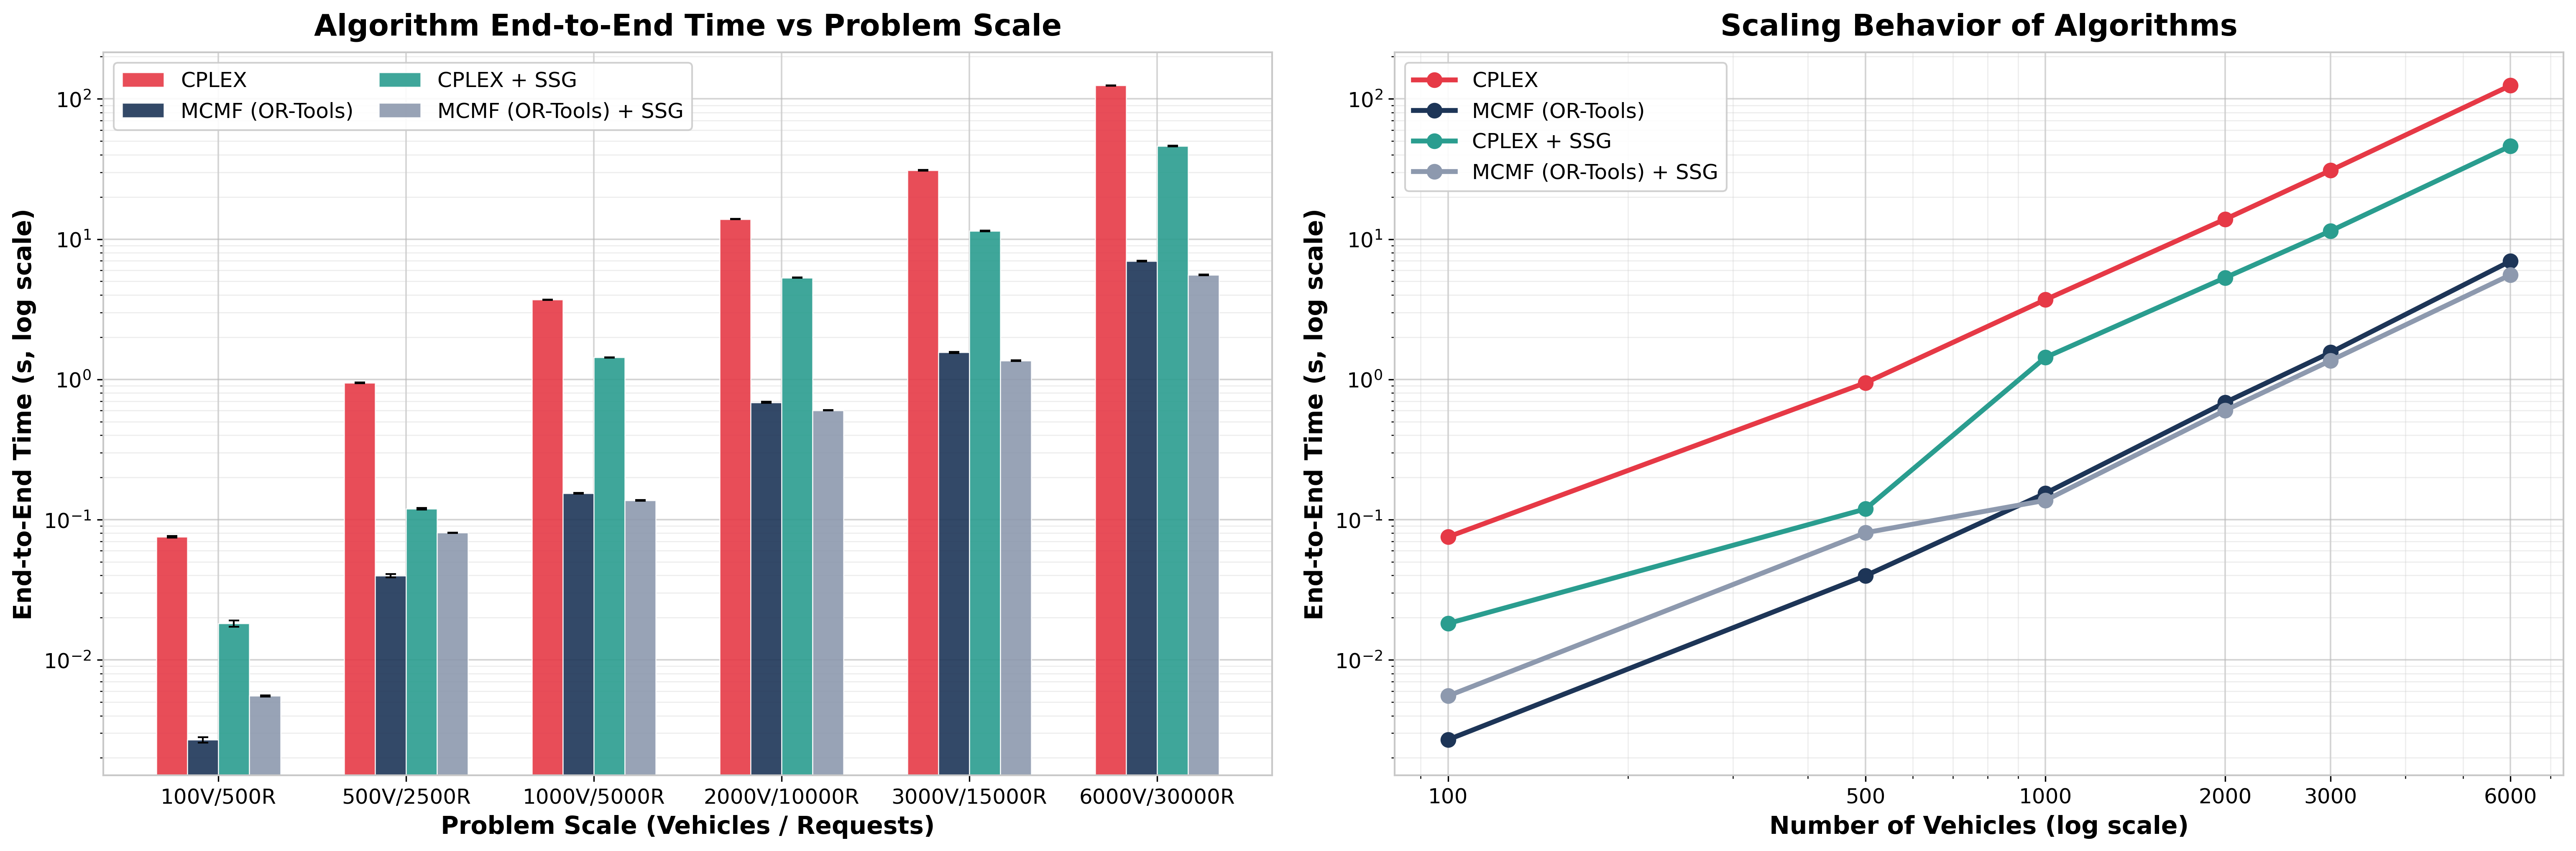

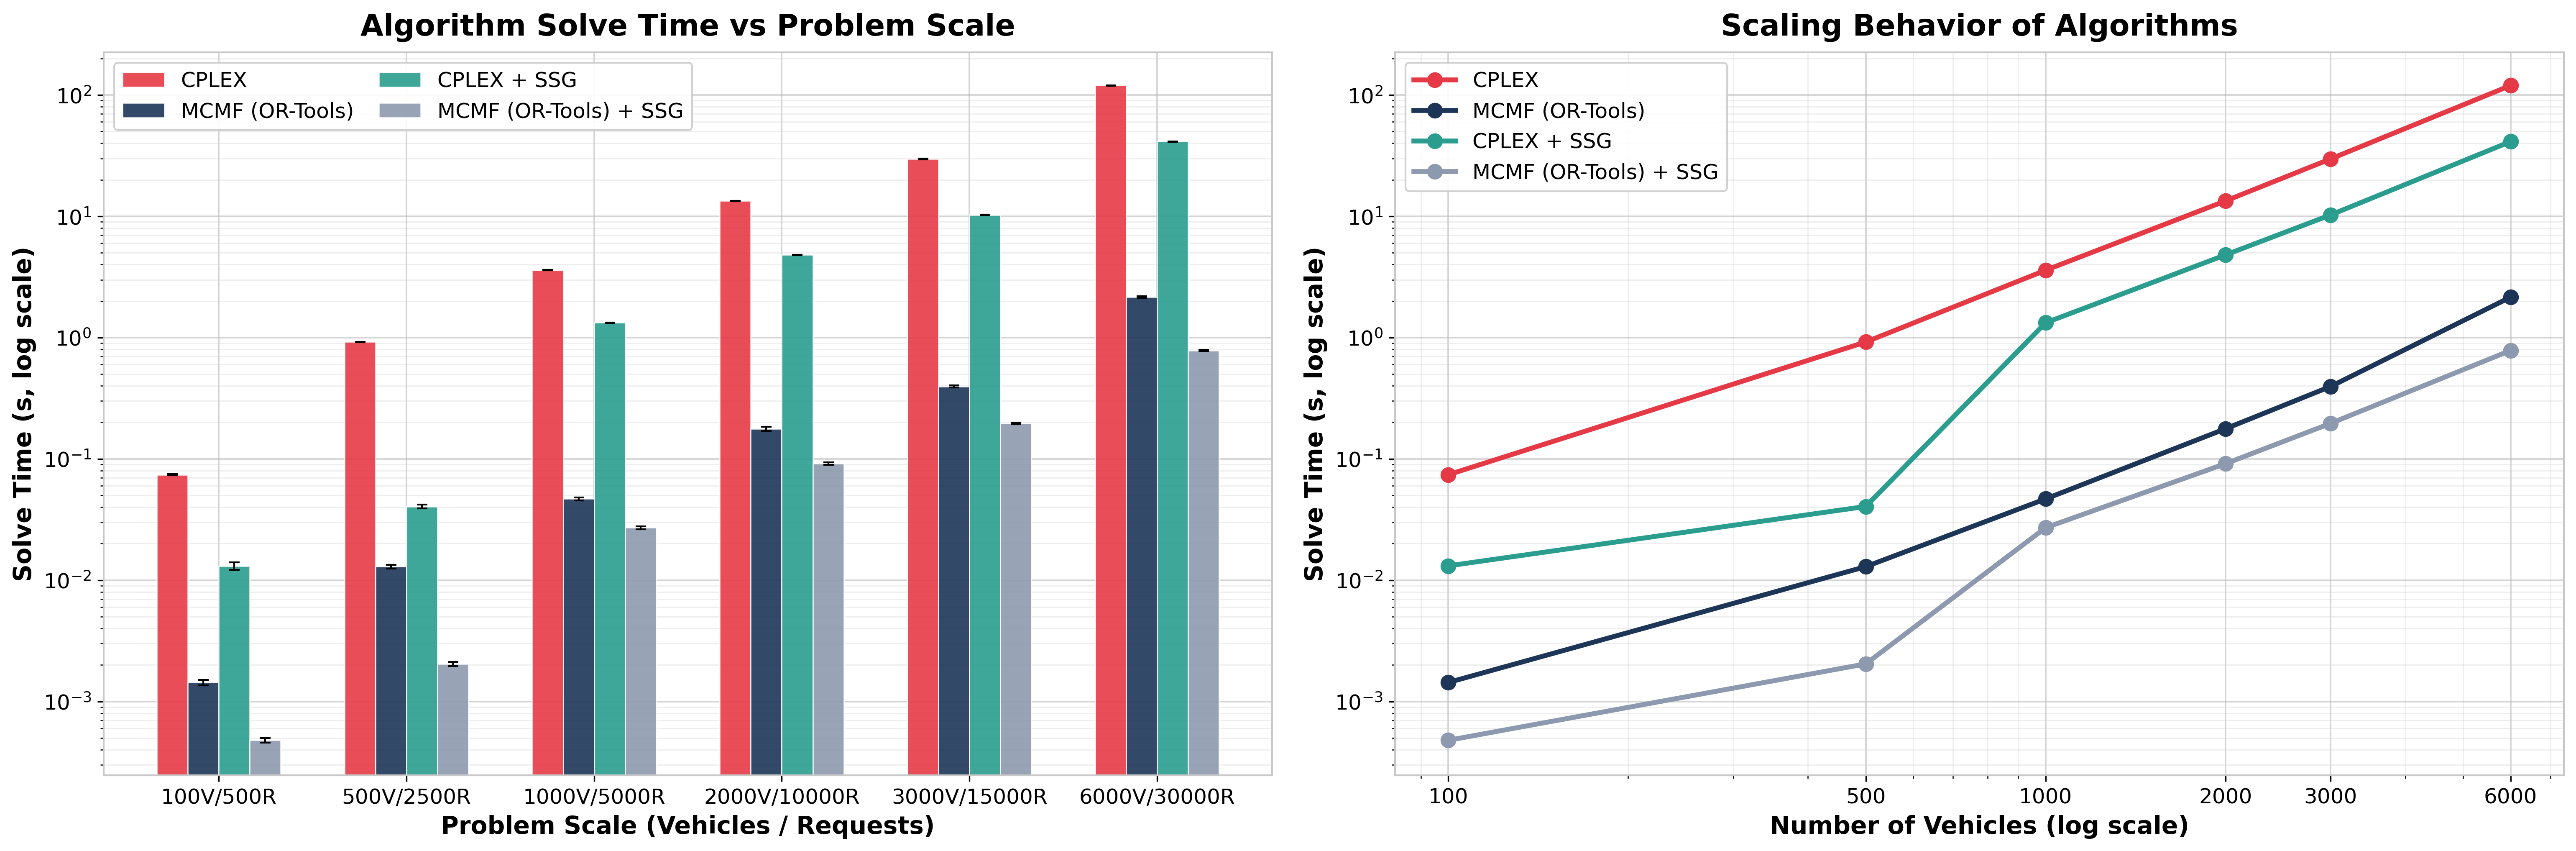

PNG / PDF / SVG 和作图统计已保存到：results/cplex_mcmf_ssg/figures


In [6]:
plotted_statistics = []
for scenario in scenarios:
    title = raw.loc[raw.scenario.eq(scenario), "scenario_title"].iloc[0]
    display(Markdown(f"### {title} (`{scenario}`)"))
    for metric in METRICS_TO_PLOT:
        plotted_statistics.append(plot_scenario(raw, scenario, metric))
if SAVE_FIGURES:
    print(f"PNG / PDF / SVG 和作图统计已保存到：{figure_dir}")


## 检查大规模是否出现净加速

表中 `total_speedup` = 完整 MCMF 的平均总时间 / SSG+MCMF 的平均总时间；**大于 1 表示 SSG 更快**。另列同种子逐对比较的胜出次数和加速比范围，避免只看均值掩盖波动。图中趋势由数据决定，不预设 SSG 必须胜出。

高 AEV/多地区场景是结构敏感性实验，不能自动代表真实 ADP 快照，也不能把图缩小的比例直接当成总时间加速比例。

In [7]:
comparison_rows = []
for keys, group in raw.groupby(scale_keys, sort=False):
    if keys[0] not in scenarios or not {"mcmf", "ssg_mcmf"}.issubset(set(group.method)):
        continue
    pair = group.loc[group.method.isin(["mcmf", "ssg_mcmf"])].pivot(index="seed", columns="method", values="end_to_end_seconds")
    if pair.isna().any().any():
        raise ValueError("MCMF/SSG 的种子没有一一配对")
    full = group.loc[group.method.eq("mcmf")]
    reduced = group.loc[group.method.eq("ssg_mcmf")]
    ratios = pair["mcmf"] / pair["ssg_mcmf"]
    comparison_rows.append(dict(
        zip(scale_keys, keys),
        AEV=int(full.aev_vehicles.iloc[0]),
        full_edges=full.graph_edges.mean(), ssg_edges=reduced.graph_edges.mean(),
        edge_reduction_pct=100*reduced.edge_reduction_ratio.mean(),
        full_total_s=full.end_to_end_seconds.mean(), ssg_total_s=reduced.end_to_end_seconds.mean(),
        total_speedup=full.end_to_end_seconds.mean()/reduced.end_to_end_seconds.mean(),
        solve_speedup=full.solve_seconds.mean()/reduced.solve_seconds.mean(),
        ssg_faster_seeds=int((ratios > 1).sum()), seeds=len(ratios),
        paired_speedup_min=ratios.min(), paired_speedup_max=ratios.max(),
        paired_speedup_geomean=np.exp(np.log(ratios).mean()),
    ))
comparison = pd.DataFrame(comparison_rows)
if len(comparison):
    display(comparison.round(4))
    if SAVE_FIGURES:
        comparison.to_csv(figure_dir / "mcmf_ssg_scaling_comparison.csv", index=False)
else:
    print("本次未同时测试 MCMF 与 SSG+MCMF。")


,scenario,vehicles,requests,charging,relocation,AEV,full_edges,ssg_edges,edge_reduction_pct,full_total_s,ssg_total_s,total_speedup,solve_speedup,ssg_faster_seeds,seeds,paired_speedup_min,paired_speedup_max,paired_speedup_geomean
0,adp_control,100,500,20,10,50,2020.3,232.8,88.4783,0.0024,0.0044,0.5346,2.6392,0,10,0.5025,0.6022,0.5331
1,adp_control,500,2500,100,50,250,19596.6,11146.3,43.2267,0.0285,0.0437,0.6521,1.3285,0,10,0.6291,0.6931,0.6520
2,adp_control,1000,5000,200,100,500,69181.9,60470.0,12.5927,0.1160,0.1170,0.9909,1.0333,4,10,0.9661,1.0246,0.9910
3,adp_control,2000,10000,400,200,1000,258357.1,224628.9,13.0549,0.4487,0.4445,1.0095,1.0747,10,10,1.0014,1.0394,1.0094
4,adp_control,3000,15000,600,300,1500,567484.9,492367.9,13.2368,0.9968,0.9813,1.0157,1.1145,10,10,1.0038,1.0300,1.0157
5,adp_control,6000,30000,1200,600,3000,2215200.2,1917715.0,13.4293,3.9760,3.9246,1.0131,1.1216,10,10,1.0027,1.0280,1.0131
6,reloc_rich,100,500,20,200,50,3037.1,232.8,92.3351,0.0028,0.0055,0.5029,2.9482,0,10,0.4556,0.5752,0.5025
7,reloc_rich,500,2500,100,1000,250,44240.9,11136.2,74.8586,0.0392,0.0702,0.5585,1.8451,0,10,0.5188,0.5855,0.5583
8,reloc_rich,1000,5000,200,2000,500,166155.0,60007.4,63.8849,0.1512,0.1367,1.1062,1.7781,10,10,1.0654,1.1224,1.1063
9,reloc_rich,2000,10000,400,4000,1000,641729.5,223941.4,65.1035,0.6794,0.5985,1.1352,1.9942,10,10,1.1215,1.1549,1.1352
